<a href="https://colab.research.google.com/github/raniellyhissamori-hub/CALCULO-NUMERICO/blob/main/Anima%C3%A7%C3%A3o_da_Elimina%C3%A7%C3%A3o_de_Gauss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrantes: Ana Laura Lopes e Ranielly Hissamori

✅ GIF gerado com sucesso: 'resolucao_sistemas.gif'



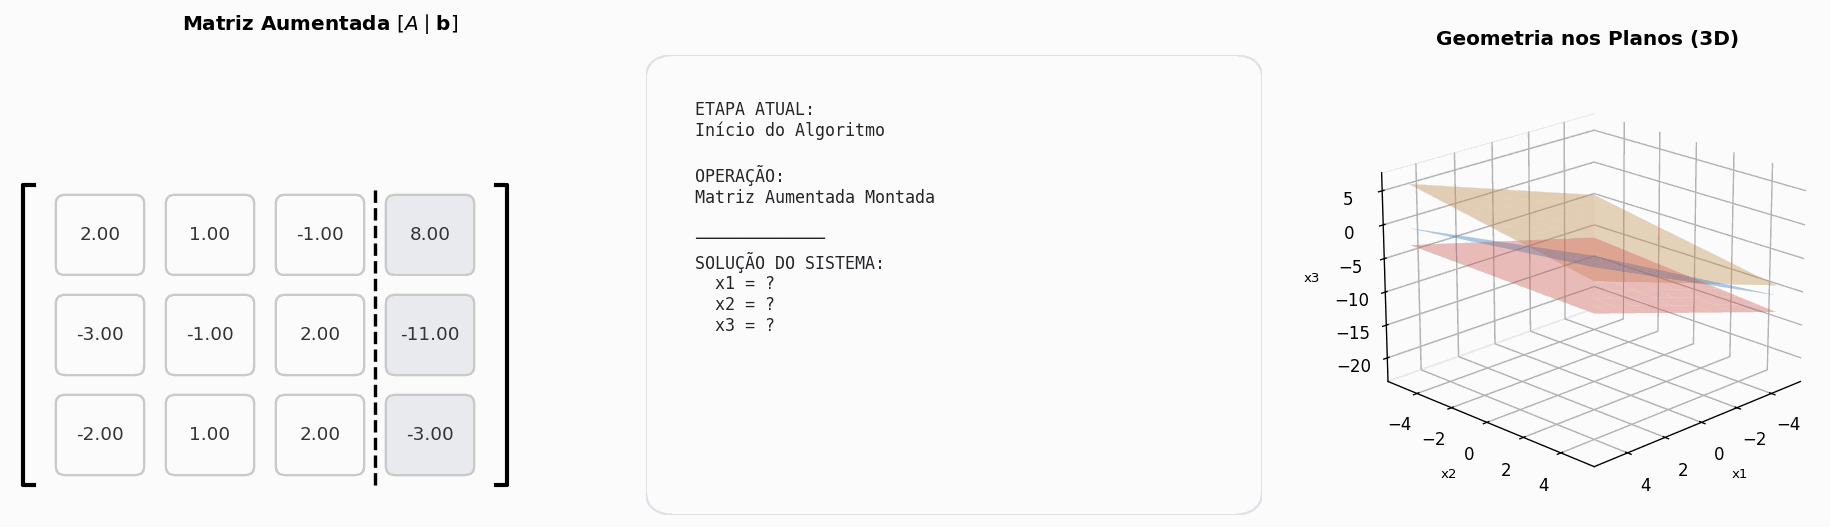

In [7]:
# Instala bibliotecas necessárias no Colab
!pip install imageio matplotlib numpy -q

import os
import imageio.v2 as imageio
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

np.set_printoptions(precision=4, suppress=True)


def desenhar_painel_passo(
    M,
    A_orig,
    b_orig,
    titulo,
    operacao_str,
    pivo_pos=None,
    linha_ativa=None,
    solucao_parcial=None,
    filename="passo.png",
):
    """Gera um Dashboard de 3 painéis:
    1. Matriz Aumentada estilizada com colchetes
    2. Status e Operações do algoritmo
    3. Visualização Geométrica (Plano 2D ou Espaço 3D)
    """
    rows, cols = M.shape
    n = rows

    # Configuração da figura com 3 subplots
    fig = plt.figure(figsize=(16, max(4.5, rows * 1.1)), facecolor="#f8f9fa")

    # ==========================================
    # PAINEL 1: MATRIZ AUMENTADA [A | b]
    # ==========================================
    ax_mat = fig.add_subplot(1, 3, 1)
    ax_mat.set_facecolor("#f8f9fa")
    ax_mat.axis("off")
    ax_mat.set_xlim(-0.8, cols + 0.8)
    ax_mat.set_ylim(-0.8, rows + 0.8)

    for r in range(rows):
        for c in range(cols):
            val = M[r, c]
            if abs(val) < 1e-12:
                val = 0.0

            y_pos = rows - 1 - r

            bg_color = "white"
            edge_color = "#cccccc"
            font_weight = "normal"
            text_color = "#333333"

            if pivo_pos and (r, c) == pivo_pos:
                bg_color = "#28a745"  # Verde para o Pivô
                edge_color = "#1e7e34"
                text_color = "white"
                font_weight = "bold"
            elif linha_ativa == r:
                bg_color = "#fff3cd"  # Amarelo para linha ativa
                edge_color = "#ffecb3"
            elif c == cols - 1:
                bg_color = "#e9ecef"  # Cinza para o vetor b

            rect = patches.FancyBboxPatch(
                (c - 0.38, y_pos - 0.38),
                0.76,
                0.76,
                facecolor=bg_color,
                edgecolor=edge_color,
                boxstyle="round,pad=0.02,rounding_size=0.08",
                linewidth=1.5,
            )
            ax_mat.add_patch(rect)

            ax_mat.text(
                c,
                y_pos,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight=font_weight,
                color=text_color,
            )

    # Linha tracejada separando [A | b]
    ax_mat.plot(
        [cols - 1.5, cols - 1.5],
        [-0.5, rows - 0.5],
        color="#000000",
        linestyle="--",
        linewidth=2,
    )

    # Desenho dos Colchetes
    ax_mat.plot(
        [-0.6, -0.7, -0.7, -0.6],
        [-0.5, -0.5, rows - 0.5, rows - 0.5],
        color="black",
        lw=2.5,
    )
    ax_mat.plot(
        [cols - 0.4, cols - 0.3, cols - 0.3, cols - 0.4],
        [-0.5, -0.5, rows - 0.5, rows - 0.5],
        color="black",
        lw=2.5,
    )
    ax_mat.set_title(
        "Matriz Aumentada $[A \\mid \\mathbf{b}]$",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )

    # ==========================================
    # PAINEL 2: STATUS E OPERAÇÕES
    # ==========================================
    ax_info = fig.add_subplot(1, 3, 2)
    ax_info.set_facecolor("#ffffff")
    ax_info.axis("off")

    rect_info = patches.FancyBboxPatch(
        (0.02, 0.02),
        0.96,
        0.96,
        facecolor="white",
        edgecolor="#dee2e6",
        transform=ax_info.transAxes,
        boxstyle="round,pad=0.02,rounding_size=0.05",
        linewidth=1.5,
    )
    ax_info.add_patch(rect_info)

    info_text = f"ETAPA ATUAL:\n{titulo}\n\n"
    info_text += f"OPERAÇÃO:\n{operacao_str}\n\n"
    info_text += "─────────────\n"

    if solucao_parcial is not None:
        info_text += "SOLUÇÃO DO SISTEMA:\n"
        for i, val in enumerate(solucao_parcial):
            if np.isnan(val):
                info_text += f"  x{i+1} = ?\n"
            else:
                info_text += f"  x{i+1} = {val:.4f}\n"

    ax_info.text(
        0.08,
        0.90,
        info_text,
        transform=ax_info.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        family="monospace",
        color="#212529",
    )

    # ==========================================
    # PAINEL 3: GEOMETRIA DO SISTEMA (PLANO 2D/3D)
    # ==========================================
    if n == 2:
        ax_geom = fig.add_subplot(1, 3, 3)
        ax_geom.set_title(
            "Geometria no Plano (2D)", fontsize=12, fontweight="bold"
        )
        colors = ["#d9534f", "#0275d8"]

        x_vals = np.linspace(-10, 10, 200)

        for i in range(2):
            a1, a2 = A_orig[i, 0], A_orig[i, 1]
            bi = b_orig[i]
            if abs(a2) > 1e-12:
                y_vals = (bi - a1 * x_vals) / a2
                ax_geom.plot(
                    x_vals,
                    y_vals,
                    label=f"Eq {i+1}",
                    color=colors[i],
                    linewidth=2,
                )
            else:
                ax_geom.axvline(
                    x=bi / a1, label=f"Eq {i+1}", color=colors[i], linewidth=2
                )

        if solucao_parcial is not None and not np.isnan(solucao_parcial).any():
            ax_geom.plot(
                solucao_parcial[0],
                solucao_parcial[1],
                "ro",
                markersize=8,
                label="Solução",
            )
            ax_geom.annotate(
                f"({solucao_parcial[0]:.2f}, {solucao_parcial[1]:.2f})",
                (solucao_parcial[0], solucao_parcial[1]),
                textcoords="offset points",
                xytext=(10, 10),
                ha="center",
                fontweight="bold",
            )

        ax_geom.set_xlim(-10, 10)
        ax_geom.set_ylim(-10, 10)
        ax_geom.axhline(0, color="black", lw=0.5, ls="--")
        ax_geom.axvline(0, color="black", lw=0.5, ls="--")
        ax_geom.grid(True, linestyle=":", alpha=0.6)
        ax_geom.legend(loc="upper right", fontsize=8)

    elif n == 3:
        ax_geom = fig.add_subplot(1, 3, 3, projection="3d")
        ax_geom.set_title(
            "Geometria nos Planos (3D)", fontsize=12, fontweight="bold"
        )
        colors = ["#d9534f", "#0275d8", "#f0ad4e"]

        # Malha de pontos para os planos
        x_range = np.linspace(-5, 5, 10)
        y_range = np.linspace(-5, 5, 10)
        X, Y = np.meshgrid(x_range, y_range)

        for i in range(3):
            a1, a2, a3 = A_orig[i, 0], A_orig[i, 1], A_orig[i, 2]
            bi = b_orig[i]
            if abs(a3) > 1e-12:
                Z = (bi - a1 * X - a2 * Y) / a3
                ax_geom.plot_surface(
                    X, Y, Z, alpha=0.35, color=colors[i], edgecolor="none"
                )

        if solucao_parcial is not None and not np.isnan(solucao_parcial).any():
            ax_geom.scatter(
                solucao_parcial[0],
                solucao_parcial[1],
                solucao_parcial[2],
                color="red",
                s=60,
                label="Solução",
            )

        ax_geom.set_xlabel("x1", fontsize=8)
        ax_geom.set_ylabel("x2", fontsize=8)
        ax_geom.set_zlabel("x3", fontsize=8)
        ax_geom.view_init(elev=20, azim=45)

    else:
        # Para n > 3, exibe mensagem sobre a impossibilidade de projeção 2D/3D
        ax_geom = fig.add_subplot(1, 3, 3)
        ax_geom.axis("off")
        ax_geom.text(
            0.5,
            0.5,
            f"Dimensão {n}D\n(Não projetável no plano)",
            ha="center",
            va="center",
            fontsize=11,
            color="#6c757d",
        )

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight", dpi=120)
    plt.close()


def resolver_e_gerar_gif(A_input, b_input, gif_filename="resolucao_sistemas.gif"):
    """Eliminação de Gauss com acompanhamento matricial e geométrico."""
    A = np.array(A_input, dtype=float, copy=True)
    b = np.array(b_input, dtype=float, copy=True)
    n = len(b)

    M = np.column_stack([A, b])

    filenames = []
    step_count = 0
    x_parcial = np.full(n, np.nan)

    # Frame 1: Inicial
    fname = f"frame_{step_count:03d}.png"
    desenhar_painel_passo(
        M,
        A,
        b,
        "Início do Algoritmo",
        "Matriz Aumentada Montada",
        solucao_parcial=x_parcial,
        filename=fname,
    )
    filenames.append(fname)
    step_count += 1

    # Eliminação de Gauss
    for k in range(n - 1):
        # Pivoteamento Parcial
        p = k + np.argmax(np.abs(M[k:, k]))

        if p != k:
            M[[k, p], :] = M[[p, k], :]
            fname = f"frame_{step_count:03d}.png"
            desenhar_painel_passo(
                M,
                A,
                b,
                f"Pivoteamento (Coluna {k+1})",
                f"Troca: Linha {k+1} <-> Linha {p+1}",
                linha_ativa=k,
                solucao_parcial=x_parcial,
                filename=fname,
            )
            filenames.append(fname)
            step_count += 1

        pivo = M[k, k]
        if abs(pivo) < 1e-12:
            raise ValueError("Sistema Singular ou sem solução única.")

        # Destaque do Pivô
        fname = f"frame_{step_count:03d}.png"
        desenhar_painel_passo(
            M,
            A,
            b,
            f"Seleção de Pivô (Etapa {k+1})",
            f"Pivô = {pivo:.2f} na pos ({k+1},{k+1})",
            pivo_pos=(k, k),
            solucao_parcial=x_parcial,
            filename=fname,
        )
        filenames.append(fname)
        step_count += 1

        # Zerar elementos abaixo
        for i in range(k + 1, n):
            fator = M[i, k] / M[k, k]
            M[i, k:] -= fator * M[k, k:]

            fname = f"frame_{step_count:03d}.png"
            desenhar_painel_passo(
                M,
                A,
                b,
                f"Eliminação na Linha {i+1}",
                f"L{i+1} = L{i+1} - ({fator:.2f})*L{k+1}",
                pivo_pos=(k, k),
                linha_ativa=i,
                solucao_parcial=x_parcial,
                filename=fname,
            )
            filenames.append(fname)
            step_count += 1

    # Substituição Regressiva
    U = M[:, :-1]
    c = M[:, -1]

    for i in range(n - 1, -1, -1):
        x_parcial[i] = (c[i] - U[i, i + 1 :] @ x_parcial[i + 1 :]) / U[i, i]

        fname = f"frame_{step_count:03d}.png"
        desenhar_painel_passo(
            M,
            A,
            b,
            "Substituição Regressiva",
            f"Calculado x{i+1} = {x_parcial[i]:.4f}",
            solucao_parcial=x_parcial,
            filename=fname,
        )
        filenames.append(fname)
        step_count += 1

    # Compilação do GIF
    images = [imageio.imread(fn) for fn in filenames]
    images.extend([images[-1]] * 4)
    imageio.mimsave(gif_filename, images, fps=1)

    for fn in filenames:
        if os.path.exists(fn):
            os.remove(fn)

    print(f"✅ GIF gerado com sucesso: '{gif_filename}'\n")
    return x_parcial


# ==============================================================================
# CONFIGURAÇÃO DE TESTE (Altere os valores da matriz A e vetor b aqui)
# ==============================================================================

# Exemplo de Teste 2x2 (Desenha as retas no plano 2D)
A_2x2 = np.array([[2.0, 1.0], [1.0, -1.0]])
b_2x2 = np.array([4.0, 1.0])

# Exemplo de Teste 3x3 (Desenha os planos no espaço 3D)
A_3x3 = np.array([[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]])
b_3x3 = np.array([8.0, -11.0, -3.0])

# Execução (Altere A_3x3 por A_2x2 para testar a versão 2D)
solucao = resolver_e_gerar_gif(A_3x3, b_3x3, gif_filename="resolucao_sistemas.gif")

# Apresentação do GIF no Colab
from IPython.display import Image, display

display(Image(filename="resolucao_sistemas.gif"))